### Greek Supreme Court Decisions 2024: Web Crawling, Legal Text Extraction and Exploratory Analysis ###

This notebook implements a Web crawling and scraping pipeline that extracts Greek Supreme Court(Areios Pagos) of year 2024, 
including both criminal and civil cases, from the official website into a coherent dataframe, whilst following the schema of the GreekLegalSum Hugging Face dataset.

Greek Supreme Court data available at : https://areiospagos.gr/

Hugging Face available at : https://huggingface.co/datasets/DominusTea/GreekLegalSum

## A1 : Examination of the specifications of the Hugging Face Dataset

Inspecting the GreekLegalSum dataset to **identify its schema (expected columns, data types, and field descriptions)**. Defining specifications for the target DataFrame structure, (summary fields may be unavailable for some records of 2024)

In [1]:
# reading the csv from huggingface as pandas ilbrary
import pandas as pd

df = pd.read_csv("hf://datasets/DominusTea/GreekLegalSum/hugginface_dataset.csv")

# NOTE: the dataset on appears to be splt into train category only, so there is no reason to specfy train as the source of sample representative of the dta 

# glance at the dataframe
display(df)

# data types
print("\ndata Types:")
print(df.dtypes)

# dispay a summary values and types
print("\ndataFrame Info:")
print(df.info())

df_clean = df.copy()
df_clean = df_clean.dropna()

# object_columns = df_clean.select_dtypes(include=['object']).columns

,text,summary,case_category,case_tags,subset
0,ΑΡΙΘΜΟΣ 970/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Αίτηση αναίρεσης καταδικαστικής αποφάσεως για ...,Ακυρότητα απόλυτη,"Αιτιολογίας επάρκεια, Ακυρότητα απόλυτη, Απάτη...",0.0
1,Αριθμός 1692/2009 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Καθορισμός συνολικής ποινής (άρθρο 551 ΚΠΔ) με...,Ποινή συνολική,"Ποινή συνολική, Νόμου εφαρμογή και ερμηνεία, Ε...",0.0
2,Αριθμός 92/2013 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ Π...,Καταδικαστική απόφαση για μη καταβολή χρεών πρ...,Ακυρότητα απόλυτη,"Ακυρότητα απόλυτη, Αοριστία λόγου αναιρέσεως, ...",0.0
3,Αριθμός 1502/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Αναίρεση Εισαγγελέα Αρείου Πάγου κατά αθωωτική...,Αβάσιμοι λόγοι,"Αναιρέσεως απόρριψη, Εισαγγελέας Αρείου Πάγου,...",2.0
4,Αριθμός 1501/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Κατ' εξακολούθηση απάτη κατ' επάγγελμα και κατ...,Αβάσιμοι λόγοι,"Ακυρότητα απόλυτη, Αναιρέσεως απόρριψη, Απάτη,...",1.0
...,...,...,...,...,...
8390,Αριθμός 542/2012 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Δημόσιο. Ομόρρυθμη εταιρεία. Παραγραφή. Πενταε...,NaN,NaN,0.0
8391,ΑΡΙΘΜΟΣ 764/2012 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Ορθή και αιτιολογημένη απόρριψη ισχυρισμού περ...,NaN,NaN,0.0
8392,ΑΡΙΘΜΟΣ 765/2012 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Ορθή και αιτιολογημένη καταδίκη για ανθρωποκτο...,NaN,NaN,0.0
8393,Αριθμός 766/2012 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ...,Λαθρεμπορία τσιγάρων. Εισαγωγή κατοχή και πώλη...,NaN,NaN,0.0



data Types:
text              object
summary           object
case_category     object
case_tags         object
subset           float64
dtype: object

dataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8395 entries, 0 to 8394
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   text           8395 non-null   object 
 1   summary        8395 non-null   object 
 2   case_category  6298 non-null   object 
 3   case_tags      6298 non-null   object 
 4   subset         8395 non-null   float64
dtypes: float64(1), object(4)
memory usage: 328.1+ KB
None


**The GreekLegalSum dataset consists of 8,395 records(legal decisions) and 5 columns:**
<br>`text`: column contains the full judicial decisions and is complete, with no missing values, making it the primary source of information.</br>

<br>`summary`: column provides a short description of each decision and is also fully populated in the reference dataset.</br>
<br>`case_category` contains a short category title of a case </br>
<br>`case_tags` contains legal tags that describe the case specifics. 
The `subset` column is numeric (float64) and appears to identify the dataset split, while all other columns are stored as text (object).

Note: both `case_category` and `case_tags` are only available for 6,298 entries, indicating that approximately 25% of the records lack these information.

**The final dataframe structure:**
will exclude the summary and case_tags columns, as these fields appear to be relevant only to older decisions and are not consistently available for 2024 cases and both of these fields lack information in the original dataset as well. Additionally, instead of storing the full decision text in a single column (as in the Hugging Face dataset), the information is parsed into structured fields, including the **decision number, year, department, judges, introductory text, and legal articles, making the dataset more suitable for analysis.**

Note:The text that fits summary appears to start immediately after the reference to the judges and continues until the phrase "ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ" 

## A2: Crawling and Scraping 

**Crawling and Scraping using selenium, beautifulsoup**

In [2]:
# necessary installs
# ! pip install requests
# ! pip install beautifulsoup4
# ! pip install selenium webdriver_manager
# ! pip install tqdm

In [3]:
# necessary imports
from selenium import webdriver
from selenium.webdriver.support.ui import Select
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import ElementClickInterceptedException
from webdriver_manager.chrome import ChromeDriverManager
import json
import time
from tqdm import tqdm  
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import re
import requests
from bs4 import BeautifulSoup
import csv
from tqdm import tqdm
import html
from pathlib import Path
import numpy as np

In [4]:
# Open chrome ensure incognito and timing in between clicks 
def open_chrome():
    options = Options()
    options.add_argument("--incognito")
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--disable-infobars")# make the window cleaner
    options.add_argument("--disable-notifications") # no notifs pop-ups

    # download the ChromeDriver
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=options)
    return driver

# Start and immediately close the driver (test only)
driver = open_chrome()
driver.quit()


**Driver test on Google**

In [5]:
url = 'https://www.google.com/'
driver = open_chrome()
driver.get(url)
time.sleep(5)
driver.quit()

**Automated form completion and Submission(essential to access the links of articles)**

In [6]:
import logging

# Configure logging to collectinfo about url info
logging.basicConfig(level=logging.DEBUG, format="%(levelname)s: %(message)s")

# # Log messages at different levels
# logging.debug("This is a debug message.")
# logging.info("This is an info message.")
# logging.warning("This is a warning message.")
# logging.error("This is an error message.")
# logging.critical("This is a critical message.")

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s: %(message)s"
)

logger = logging.getLogger(__name__)

Note: 
-  1 --> is for Political Decisions<br>
-  2 --> is for Criminal Decisions

In [7]:
def complete_form(driver,value, year):
    dept_value = str(value)
    year_value = str(year)
    # first select the category 
    section_dropdown = Select(driver.find_element(By.NAME, "X_TMHMA"))
    section_dropdown.select_by_value(dept_value)
    time.sleep(3)
    
    # typethe year 
    year_input = driver.find_element(By.NAME, "x_ETOS")
    year_input.send_keys(year_value)
    
    # Click submit button
    submit_form_button = driver.find_element(By.NAME, "submit_krit")
    submit_form_button.click()

In [22]:
def get_article_links(driver, url, output_path, value, year):
    driver.get(url)
    
    complete_form(driver, value, year)
    
    WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.XPATH, "//table//tr//td//a")))

    links = driver.find_elements(By.XPATH, "//table//tr//td//a")
    print(f"Found {len(links)} links")

    with open(output_path, "w", encoding="utf-8") as f:
        print("currently extracting links")
        for link in links:
            href = link.get_attribute("href")
            try:
                json.dump({"url": href}, f, ensure_ascii=False)
                f.write("\n")
            except Exception as e:
                logging.error("Error writing link:", e)

Automatic creation of json files (they are created in the same working directory)

In [9]:
# creating data folder 
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# json output files
output_path_politikes = DATA_DIR / "articles.json"
output_path_poinikes = DATA_DIR / "articles2.json"

In [10]:
# check if files were created successfully
print("Current working directory:", Path.cwd())
print("Data directory:", DATA_DIR.resolve())
print("Exists:", DATA_DIR.exists())

Current working directory: C:\Users\alex
Data directory: C:\Users\alex\data
Exists: True


**Storing article links in json format**

In [24]:
url = 'https://www.areiospagos.gr/nomologia/apofaseis.asp' # url for decisions

#open browser and collect links
driver = open_chrome()
get_article_links(driver, url,output_path_politikes,1,2024)
# pause to reduce the load on the website
time.sleep(3)
get_article_links(driver, url,output_path_poinikes, 2, 2024)

driver.quit()

In [12]:
print(output_path_politikes)
print(output_path_politikes.exists())
print(output_path_poinikes)
print(output_path_poinikes.exists())

data\articles.json
True
data\articles2.json
True


**Helper functions and regex scripts used for scraping**

In [13]:
# regex script to extract text between 2 keywords
def keyword_search(test_text, keyword1, keyword2=None):
    # single keyword case
    if keyword2 is None:
        match = re.search(rf'\b{re.escape(keyword1)}\b', test_text)
        
        if match:
            extracted = match.group(0)
            print(extracted)
     
    # double keyword case
    else:
        # include keyword1 and keyword2 
        pattern = rf'{re.escape(keyword1)}(.*?{re.escape(keyword2)})'
        match = re.search(pattern, test_text)
        
        if match:
            extracted = match.group(1).strip()
            return extracted

In [14]:
def normalize_text(text):
    return re.sub(r'\s+', ' ', text).strip()

def keyword_search(text, keyword1, keyword2):
    text = normalize_text(text)
    pattern = rf"{re.escape(keyword1)}.*?{re.escape(keyword2)}"
    match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
    return match.group(0).strip() if match else None

def extract_sentence_from_keyword(text, keyword):
    pattern = rf"{re.escape(keyword)}.*?\."
    match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
    return match.group(0).strip() if match else None

def subtract_text(text, *substrings):
    for s in substrings:
        if s:
            text = text.replace(s, '')
    return text.strip()

def find_intro_text(full_text, section_heading):
    full_text = normalize_text(full_text)

    # 1. Extract main intro text between 2 keywords
    main_text = keyword_search(full_text, "ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ", "ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ")

    # 2. Extract judges
    judge_line = extract_sentence_from_keyword(main_text, "Δικαστές")

    # 3. remove and extract judges and department from the main intro
    filtered_intro = subtract_text(main_text, section_heading, judge_line)
    return filtered_intro


In [15]:
def extract_single_line(soup):
    b = soup.find('b')# find the first b occurence
    return b.get_text(strip=True)

In [16]:
def separate_line(line):
    delimiter = "/"
    number = line.split(delimiter)[0].strip()
    year = line.partition(delimiter)[2]
    return number, year  

In [17]:
def normalize_phrase(codes):
    return '|'.join(r'\.?'.join(re.escape(c) for c in code) + r'\.?' for code in codes)

# regex script
def extract_articles(text, start_keywords, end_keywords, max_words_between=10):
    start = '|'.join(re.escape(k) for k in start_keywords)
    end = normalize_phrase(end_keywords)

    pattern = (
        rf'\b(?:{start})'                        # start keyword
        rf'(?:\s+\S+){{0,{max_words_between}}}'  # up to N words
        rf'\s+(?:{end})'                         # end keyword
    )

    # Use re.findall to get full match
    matches = re.findall(pattern, text, flags=re.IGNORECASE)
    return [match.strip() for match in matches]


In [18]:
def extract_line_index(soup, i):
    #finding specific tag which cointains information about the deprtment
    p_tag = soup.find('p', align='justify')

    # replace <br> with /n to aPply split easily
    for br in p_tag.find_all('br'):
        br.replace_with('\n')

    lines = p_tag.get_text(separator="\n", strip=True).split('\n')

    return lines[i].strip()

In [19]:
def extract_names(text):
    pattern = r'δικαστές\s*[:;,]?\s*(.*?\.)'  # tolerate :;, and noth
    match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)# tolerate lowercase/uppercase
    return match.group(1).strip()

### Final Script for Scraping information and constructing the Dataset

In [20]:
# Remove newlines etc to normalisze text
def normalize_text(text):
    text = re.sub(r'\s+', ' ', text)  
    return text.strip()

def normalize_rows(text):
    return html.unescape(text.replace('\n', ' ').replace('\r', ' ').strip())

def scrape_url(input_jsn, output_csv, article_keywords, law_codes):
    try:
        with open(input_jsn, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f if line.strip()]
    except Exception as e:
        logger.error(f"Errr opening input json: {e}")
#         print(f"Errr opening input json: {e}")
        lines = []# output npth just in case

    # Write CSV column titles
    try:
        with open(output_csv, 'a', newline='', encoding='utf-8') as dataset_csv:
            writer = csv.writer(dataset_csv)
            writer.writerow(["number", "year", "dept", "intro_text", "judges", "articles"]) #writing the names of the columns
    except Exception as e:
        logger.error(f"Error: couldn't write the header: {e}")
        return
        
    # Loop through each URL
    for line in tqdm(lines, desc="Scraping", unit="url"):
        try:
            data = json.loads(line)
            url = data.get("url")

            response = requests.get(url, timeout=10)
            response.raise_for_status()

            response.encoding = response.apparent_encoding  # Greek encoding didnt work, use auto detection

            # Parse HTML
            soup = BeautifulSoup(response.text, 'html.parser')
            
            # Find all paragraphs
            paragraphs = soup.find_all('p')

            # replace <br> tags 
            for p in paragraphs:
                for br in p.find_all('br'):
                    br.replace_with("\n")

            # Extract text from paragraphs
            paragraph_texts = [p.get_text(separator=" ", strip=True) for p in paragraphs]
            full_text = " ".join(paragraph_texts).strip()

            # NOrmalize text
            full_text = normalize_text(full_text)
        
            # Apply keyword search
            number = separate_line(extract_single_line(soup))[0]
            logging.debug(f"number: {number}")
            
            year = separate_line(extract_single_line(soup))[1]
            logging.debug(f"year: {year}")
            
            dept = extract_line_index(soup, 2)
            logging.debug(f"dept: {dept}")
            
            judges = extract_names(full_text)
            logging.debug(f"judges: {judges}")

            intro_text = find_intro_text(full_text, dept)
            logging.debug(f"intro_text: {intro_text}")
            
            articles = extract_articles(full_text, article_keywords, law_codes)
            
    
            with open(output_csv, 'a', newline='', encoding='utf-8') as dataset_csv:
                writer = csv.writer(dataset_csv, quoting=csv.QUOTE_ALL)  # quote everything
                writer.writerow([
                    normalize_text(number),
                    normalize_text(year),
                    normalize_text(dept),
                    normalize_text(intro_text),
                    normalize_text(judges),
                    "; ".join(articles) if isinstance(articles, list) else normalize_text(articles)
                ])


        except requests.exceptions.RequestException as e:
            logger.error(f"Failed to fetch {url}: {e}")
            continue
    
        except Exception as e:
            logger.error(f"Error with {url}: {e}")
            continue

    print("Scraping completed.")

In [21]:
from pathlib import Path

print(Path.cwd())

C:\Users\alex


In [59]:
output_csv = DATA_DIR / "dataset.csv"

**Scraping Political articles**

In [60]:
# File paths
scrape_url(output_path_politikes , output_csv,["άρθρου", "άρθρων"], ["Α.Κ", "ΚΠολΔ"])

Scraping:   0%|                                                                      | 1/1974 [00:00<18:10,  1.81url/s]

11
 2024
Β1' Πολιτικό Τμήμα
Λουκά Μόρφη, Αντιπρόεδρο του Αρείου Πάγου, Δήμητρα Ζώη, Ιωάννα Μαργέλλου-Μπουλταδάκη, Ιωάννη Δουρουκλάκη και Δημητρία Στρούζα-Ξένου, Αρεοπαγίτες.
Error with https://www.areiospagos.gr/nomologia/apofaseis_DISPLAY.asp?cd=RWKDTA2X1554EH8YXW0M7NFLRRV23P&apof=11_2024&info=%D0%CF%CB%C9%D4%C9%CA%C5%D3%20-%20%20%C21: expected string or bytes-like object, got 'NoneType'


Scraping:   0%|                                                                      | 2/1974 [00:00<15:45,  2.09url/s]

12
 2024
Β1' Πολιτικό Τμήμα
Λουκά Μόρφη, Αντιπρόεδρο του Αρείου Πάγου, Δήμητρα Ζώη, Ιωάννα Μαργέλλου-Μπουλταδάκη, Ιωάννη Δουρουκλάκη και Δημητρία Στρούζα-Ξένου, Αρεοπαγίτες.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  Συνήλθε σε δημόσια συνεδρίαση στο κατάστημά του, την 1η Φεβρουαρίου 2022, με την παρουσία και της Γραμματέως Ε. Τ., για να δικάσει την υπόθεση, μεταξύ: Του αναιρεσείοντος: ... (Ν.Π.Ι.Δ.) με την επωνυμία "...", όπως εκπροσωπείται νόμιμα, που εδρεύει στα ... και παραστάθηκε δια δηλώσεως (ΚΠολΔ 242 παρ.2) του πληρεξουσίου δικηγόρου Ευριπίδη Κωνσταντίνου, ο οποίος κατέθεσε προτάσεις. Του αναιρεσίβλητου: Β. Σ. του Κ., κατοίκου ... που παραστάθηκε δια δηλώσεως (ΚΠολΔ 242 παρ. 2) του πληρεξουσίου δικηγόρου Απόστολου Ανδρεόπουλου, ο οποίος δεν κατέθεσε προτάσεις. Η ένδικη διαφορά άρχισε με την από 6-11-2017 αγωγή του ήδη αναιρεσείοντος, που κατατέθηκε στο Μονομελές Πρωτοδικείο ... Εκδόθηκαν η 81/2018 οριστική απόφαση του πρωτοβαθμίου δικαστηρίου και, κατόπιν ασκήσεως ε

Scraping:   0%|                                                                      | 3/1974 [00:01<16:02,  2.05url/s]

...

1866
 2024
Α3' Πολιτικό Τμήμα
Αικατερίνη Κρυσταλλίδου, Αντιπρόεδρο του Αρείου Πάγου, Χρήστο Κατσιάνη, Στέφανο-Σπυρίδωνα Πανταζόπουλο, Κορνηλία Πανούτσου και Ηλία Γιαρένη-Εισηγητή, Αρεοπαγίτες.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  ΣΥΝΕΔΡΙΑΣΕ δημόσια στο ακροατήριό του, στις 25 Σεπτεμβρίου 2023, με την παρουσία και της Γραμματέως Μ. Σ., για να δικάσει την υπόθεση μεταξύ: Των αναιρεσειόντων: 1)Ε. χήρας Ι. Δ., το γένος Θ. Κ., 2)Δ. Δ. του Ι., 3)Ε. συζύγου Β. Μ., το γένος Ι. Δ., κατοίκων ..., οι οποίοι δεν εκπροσωπήθηκαν στο ακροατήριο. Των αναιρεσιβλήτων: 1)Α. Ζ. του Γ., κατοίκου ..., ο οποίος εκπροσωπήθηκε από την πληρεξούσια δικηγόρο Σοφία Ζιάκα με δήλωση κατ' άρθρο 242 παρ. 2 ΚΠολΔ και κατέθεσε προτάσεις, 2)Ι. Φ. του Θ., κατοίκου ..., ο οποίος εκπροσωπήθηκε από την πληρεξούσια δικηγόρο Παρασκευή Κατσαρού με δήλωση κατ' άρθρο 242 παρ. 2 ΚΠολΔ και κατέθεσε προτάσεις, 3)Ανώνυμης Εταιρείας με την επωνυμία "EUROMEDICA ΑΝΩΝΥΜΗ ΕΤΑΙΡΕΙΑ ΠΑΡΟΧΗΣ ΙΑΤΡΙΚΩΝ ΥΠΗΡΕΣΙΩΝ", που εδρεύει

Scraping: 100%|██████████████████████████████████████████████████████████████████▉| 1973/1974 [15:54<00:00,  1.71url/s]

1868
 2024
Α3' Πολιτικό Τμήμα
Αικατερίνη Κρυσταλλίδου, Αντιπρόεδρο του Αρείου Πάγου, Χρήστο Κατσιάνη, Στέφανο-Σπυρίδωνα Πανταζόπουλο, Κορνηλία Πανούτσου και Ηλία Γιαρένη-Εισηγητή, Αρεοπαγίτες.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  Συνεδρίασε δημόσια στο ακροατήριό του, στις 26 Φεβρουαρίου 2024, με την παρουσία και της Γραμματέως Μ. Σ., για να δικάσει την υπόθεση μεταξύ: Της αναιρεσείουσας: Ανώνυμης εταιρείας "NOVA TELECOMMUNICATIONS & MEDIA ΜΟΝΟΠΡΟΣΩΠΗ Α.Ε.", που εδρεύει στην Αθήνα και εκπροσωπείται νόμιμα, πρώην "WIND ΕΛΛΑΣ ΤΗΛΕΠΙΚΟΙΝΩΝΙΕΣ ΜΟΝΟΠΡΟΣΩΠΗ ΑΝΩΝΥΜΗ ΕΜΠΟΡΙΚΗ & ΒΙΟΜΗΧΑΝΙΚΗ ΕΤΑΙΡΕΙΑ", ως καθολικής διαδόχου λόγω συγχώνευσης με απορρόφηση της ανώνυμης εταιρίας με την επωνυμία "NOVA BROADCASTING ΜΟΝΟΠΡΟΣΩΠΗ Α.Ε." πρώην "NOVA BROADCASTING A.E.", πρώην "FORTHNET ΑΝΩΝΥΜΗ ΕΤΑΙΡΕΙΑ ΣΥΝΔΡΟΜΗΤΙΚΗΣ ΤΗΛΕΟΡΑΣΗΣ-ΠΑΡΟΧΗΣ ΤΗΛΕΠΙΚΟΙΝΩΝΙΑΚΩΝ ΠΛΗΡΟΦΟΡΙΩΝ ΚΑΙ ΣΥΜΜΕΤΟΧΩΝ" με τον διακριτικό τίτλο "FORTHNET MEDIA A.E.", ως καθολικής διαδόχου λόγω συγχώνευσης με απορρόφηση της εταιρε

Scraping: 100%|███████████████████████████████████████████████████████████████████| 1974/1974 [15:55<00:00,  2.07url/s]

1967
 2024
Α3' Πολιτικό Τμήμα
Χρήστο Κατσιάνη, Προεδρεύοντα Αρεοπαγίτη, Στέφανο-Σπυρίδωνα Πανταζόπουλο, Κορνηλία Πανούτσου, Χρυσούλα Πλατιά και Ηλία Γιαρένη-Εισηγητή, Αρεοπαγίτες.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  Συνεδρίασε δημόσια στο ακροατήριό του, στις 11 Μαρτίου 2024, με την παρουσία και της Γραμματέως Μ. Σ., για να δικάσει την υπόθεση μεταξύ: Των αναιρεσειόντων: 1.Π. Γ. (P. G.) του K., και 2.Γ. Γ. (K. G.) του Π., κατοίκων ..., οι οποίοι παραστάθηκαν με την πληρεξουσία δικηγόρο Αναστασία Σίνου και κατέθεσαν προτάσεις. Του αναιρεσιβλήτου: Π. Τ. του Ρ., κατοίκου ..., ο οποίος παραστάθηκε με τον πληρεξούσιο δικηγόρο Παναγιώτη Παλούκη και κατέθεσε προτάσεις. Η ένδικη διαφορά άρχισε με τις από: α)18.12.2011 αγωγή του ήδη αναιρεσιβλήτου και β)11.12.2013 αγωγή των ήδη αναιρεσειόντων, που κατατέθηκαν και συνεκδικάστηκαν στο Μονομελές Πρωτοδικείο Αθηνών. Εκδόθηκαν οι αποφάσεις: 5253/2017 μη οριστική και 9374/2021 οριστική του ίδιου Δικαστηρίου και 1430/2023 του Μονομε

### A3: Visualing some rows of the constructed csv using pandas, Comparing to HuggingsFace Dataset

In [65]:
import pandas as pd

my_data_df = pd.read_csv(output_csv, quotechar='"', encoding='utf-8')
my_data_df.head()

,number,year,dept,intro_text,judges,articles
0,number,year,dept,intro_text,judges,articles
1,12,2024,Β1' Πολιτικό Τμήμα,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Λουκά Μόρφη, Αντιπρόεδρο του Αρείου Πάγου, Δήμ...",άρθρου 559 αρ.1 εδ.α` ΚΠολΔ; άρθρου 559 αριθμό...
2,13,2024,Β1' Πολιτικό Τμήμα,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Ιωάννα Μαργέλλου-Μπουλταδάκη, Προεδρεύουσα Αρε...",άρθρου 559 αριθ. 1 εδ. α του ΚΠολΔ; άρθρου 559...
3,14,2024,Β1' Πολιτικό Τμήμα,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Ιωάννα Μαργέλλου-Μπουλταδάκη, Προεδρεύουσα Αρε...",άρθρου 559 αριθ. 1 εδ. α του ΚΠολΔ; άρθρου 559...
4,31,2024,Β1' Πολιτικό Τμήμα,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Δήμητρα Ζώη, Αντιπρόεδρο του Αρείου Πάγου, Αρι...","άρθρου 576 παρ. 1 του ΚΠολΔ; άρθρων 440, 438 κ..."


In [62]:
# File paths
scrape_url(output_path_poinikes,output_csv,article_keywords=["άρθρου", "άρθρων"],law_codes=["Π.Κ", "ΚΠΔ"])

Scraping:   0%|                                                                      | 1/1136 [00:00<10:35,  1.79url/s]

1379
 2024
Β' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ
Απόστολο Φωτόπουλο Προεδρεύοντα Αρεοπαγίτη (ως αρχαιότερο μέλος της συνθέσεως, ο οποίος ορίστηκε με την υπ'αριθμ.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  178/2024 πράξη της Πρόεδρου του Αρείου Πάγου), Ευαγγελία Στεργίου, Ελένη Θεοδωρακοπούλου, Διονυσία Νίκα και Δέσποινα Βασιλοδημητράκη- Εισηγήτρια, Αρεοπαγίτες. Συνήλθε σε δημόσια συνεδρίαση στο Κατάστημά του στις 3 Σεπτεμβρίου 2024, με την παρουσία του Αντεισαγγελέως του Αρείου Πάγου Νικόλαου Δεγαίτη και της Γραμματέως Ευθυμίας Καλογεροπούλου, για να δικάσει την αίτηση των αναιρεσειόντων - κατηγορουμένων: 1.Α. Δ. του Κ., κατοίκου ..., 2.Π. Ρ. του Δ., κατοίκου ... και 3. Χ. Δ. του Η., κατοίκου ..., οι οποίοι εκπροσωπήθηκαν από τον πληρεξούσιο δικηγόρο τους Ιωάννη-Τζανέτο Μπαλιτσάρη, για αναίρεση της υπ'αριθ. 194α, 698/2024 απόφασης του Β' Τριμελούς Εφετείου Πλημμελημάτων Αθηνών. Με υποστηρίζουσα την κατηγορία την Μ. Κ. του Π., κάτοικο Αθηνών, η οποία εκπροσωπήθηκε από τον πληρεξούσιο δ

Scraping:   0%|                                                                      | 2/1136 [00:01<10:09,  1.86url/s]

36
 2024
Ε' ΠΟΙΝΙΚΟ ΤΜΗΜΑ - ΣΕ ΣΥΜΒΟΥΛΙΟ
Μαρία Λεπενιώτη, Αντιπρόεδρο του Αρείου Πάγου, Σοφία Οικονόμου - Εισηγήτρια και Δημήτριο Τράγκα, Αρεοπαγίτες.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  Με την παρουσία και του Αντεισαγγελέα του Αρείου Πάγου Χρήστου Μπαρδάκη (γιατί κωλύεται ο Εισαγγελέας) και του Γραμματέως Γεράσιμου Βάλσαμου. Συνήλθε ως συμβούλιο σε δημόσια συνεδρίαση στο ακροατήριό του στις 22 Σεπτεμβρίου 2023, προκειμένου να αποφανθεί για την αίτηση του αιτούντος F. A. του M., κρατούμενου στο Κατάστημα Κράτησης Νιγρίτας, ο οποίος εμφανίστηκε και παραστάθηκε χωρίς πληρεξούσιο δικηγόρο, για επανάληψη της διαδικασίας που περατώθηκε με την υπ' αριθμ. 2765/2019 αμετάκλητη απόφαση του Μονομελούς Εφετείου Κακουργημάτων Αθηνών. Το Μονομελές Εφετείο Κακουργημάτων Αθηνών, με την ως άνω απόφασή του διέταξε όσα λεπτομερώς αναφέρονται σ' αυτή, και ο αιτών ζητεί τώρα την επανάληψη της διαδικασίας, για τους λόγους που αναφέρονται στην από 16.1.2023 αίτησή του, η οποία καταχωρίστ

Scraping:   0%|▏                                                                     | 3/1136 [00:01<09:00,  2.10url/s]

...

1163
 2024
B' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ
Απόστολο Φωτόπουλο, Προεδρεύοντα Αρεοπαγίτη (ως αρχαιότερο μέλος της συνθέσεως, ο οποίος ορίστηκε με την υπ' αριθμ.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  178/2024 πράξη της Πρόεδρου του Αρείου Πάγου), Ευαγγελία Στέργιου, Ελένη Θεοδωρακοπούλου, Διονυσία Νίκα και Δέσποινα Βασιλοδημητράκη - Εισηγήτρια, Αρεοπαγίτες. Συνήλθε σε δημόσια συνεδρίαση στο Κατάστημά του στις 3 Σεπτεμβρίου 2024, με την παρουσία του Αντεισαγγελέως του Αρείου Πάγου Νικόλαου Δεγαϊτη και της Γραμματέως Ε. Κ., για να δικάσει την αίτηση του αναιρεσείοντος - κατηγορουμένου Δ. Μ. του Θ., κατοίκου ..., ο οποίος εκπροσωπήθηκε από τον πληρεξούσιο δικηγόρο του Βασίλειο Κουρκουρίκα, για αναίρεση της υπ'αριθμ. 628/2024 απόφασης του Τριμελούς Εφετείου Πλημμελημάτων Θεσσαλονίκης (Β'βαθμού). Με υποστηρίζοντες την κατηγορία τους: 1.Α. Σ. του Ν. και 2. Φ. Μ. του Ι., κατοίκων ..., οι οποίοι εκπροσωπήθηκαν από τον πληρεξούσιο δικηγόρο τους Ματθαίο Μανάρα. Το Τριμελές Εφετείο Πλημμε

Scraping: 100%|██████████████████████████████████████████████████████████████████▉| 1135/1136 [08:57<00:00,  2.34url/s]

1219
 2024
Β' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ
Απόστολο Φωτόπουλο, Προεδρεύοντα Αρεοπαγίτη (ως αρχαιότερο μέλος της συνθέσεως, ο οποίος ορίστηκε με την υπ' αριθμ.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  178/2024 πράξη της Προέδρου του Αρείου Πάγου), Ευαγγελία Στεργίου, Ελένη Θεοδωρακοπούλου, Διονυσία Νίκα και Δέσποινα Βασιλοδημητράκη - Εισηγήτρια, Αρεοπαγίτες. Συνήλθε σε δημόσια συνεδρίαση στο Κατάστημά του στις 3 Σεπτεμβρίου 2024, με την παρουσία του Αντεισαγγελέα του Αρείου Πάγου Νικολάου Δεγαΐτη (γιατί κωλύεται η Εισαγγελέας) και της Γραμματέως Ε. Κ., για να δικάσει την αίτηση του αναιρεσείοντος - κατηγορουμένου Β. Τ. του Σ., κατοίκου ..., ο οποίος εκπροσωπήθηκε από τον πληρεξούσιο δικηγόρο του, Θεόδωρο Παπαηλιού, για αναίρεση της υπ'αριθμ. 2203/2024 αποφάσεως του Τριμελούς Εφετείου Πλημμελημάτων Αθηνών. Με υποστηρίζοντα την κατηγορία τον Κ. Μ. του Γ., κάτοικο ..., ο οποίος εκπροσωπήθηκε από την πληρεξούσια δικηγόρο του Αγγελική Καλογιάννη. Το Τριμελές Εφετείο Πλημμελημάτων Αθη

Scraping: 100%|███████████████████████████████████████████████████████████████████| 1136/1136 [08:58<00:00,  2.11url/s]

1226
 2024
Β' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ
Απόστολο Φωτόπουλο, Προεδρεύοντα Αρεοπαγίτη (ως αρχαιότερο μέλος της συνθέσεως, ο οποίος ορίστηκε με την υπ'αριθμ.
ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ  Συγκροτήθηκε από τους  178/2024 πράξη της Πρόεδρου του Αρείου Πάγου) - Εισηγητή, Ευαγγελία Στέργιου, Ελένη Θεοδωρακοπούλου, Διονυσία Νίκα και Δέσποινα Βασιλοδημητράκη, Αρεοπαγίτες. Συνήλθε σε δημόσια συνεδρίαση στο Κατάστημά του στις 3 Σεπτεμβρίου 2024, με την παρουσία του Αντεισαγγελέως του Αρείου Πάγου Νικόλαου Δεγαϊτη και της Γραμματέως Ε. Κ., για να δικάσει την αίτηση του αναιρεσείοντος - κατηγορουμένου Γ. Μ. του Σ., κατοίκου ..., ο οποίος εκπροσωπήθηκε από τον πληρεξούσιο δικηγόρο του Αναστάσιο Τζούνη, για αναίρεση της υπ'αριθμ. 843/2024 απόφασης του Τριμελούς Εφετείου Πλημμελημάτων Θεσσαλονίκης. Με υποστηρίζουσα την κατηγορία την ετερόρρυθμη εταιρεία με την επωνυμία: "Π. Ξ. και Σία", που τελεί υπό εκκαθάριση με εκκαθαριστή τον Κ. Σ., με έδρα τα Γιαννιτσά, η οποία εκπροσωπήθηκε από τον πληρεξούσιο δι

In [67]:
import pandas as pd

my_data_df = pd.read_csv(output_csv, quotechar='"', encoding='utf-8')
#my_data_df.head()
display(my_data_df)

,number,year,dept,intro_text,judges,articles
0,number,year,dept,intro_text,judges,articles
1,12,2024,Β1' Πολιτικό Τμήμα,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Λουκά Μόρφη, Αντιπρόεδρο του Αρείου Πάγου, Δήμ...",άρθρου 559 αρ.1 εδ.α` ΚΠολΔ; άρθρου 559 αριθμό...
2,13,2024,Β1' Πολιτικό Τμήμα,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Ιωάννα Μαργέλλου-Μπουλταδάκη, Προεδρεύουσα Αρε...",άρθρου 559 αριθ. 1 εδ. α του ΚΠολΔ; άρθρου 559...
3,14,2024,Β1' Πολιτικό Τμήμα,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Ιωάννα Μαργέλλου-Μπουλταδάκη, Προεδρεύουσα Αρε...",άρθρου 559 αριθ. 1 εδ. α του ΚΠολΔ; άρθρου 559...
4,31,2024,Β1' Πολιτικό Τμήμα,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Δήμητρα Ζώη, Αντιπρόεδρο του Αρείου Πάγου, Αρι...","άρθρου 576 παρ. 1 του ΚΠολΔ; άρθρων 440, 438 κ..."
...,...,...,...,...,...,...
2929,1161,2024,Β' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Απόστολο Φωτόπουλο, Προεδρεύοντα Αρεοπαγίτη (ω...",άρθρων 93 παρ.3 του Συντάγματος και 139 ΚΠΔ; ά...
2930,1162,2024,Β' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Απόστολο Φωτόπουλο, Προεδρεύοντα Αρεοπαγίτη (ω...",άρθρου 504 παρ. 1 ΚΠΔ
2931,1163,2024,B' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Απόστολο Φωτόπουλο, Προεδρεύοντα Αρεοπαγίτη (ω...",άρθρου 510 παρ. 1 στοιχ. Θ' του ΚΠΔ; άρθρων 93...
2932,1219,2024,Β' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ,ΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ ΠΑΓΟΥ Συγκροτήθηκε απ...,"Απόστολο Φωτόπουλο, Προεδρεύοντα Αρεοπαγίτη (ω...",άρθρων 177 παρ. 1 και 178 του Κ.Π.Δ.


### A4: Visualizing Data

Heatmap of Number of Judges involved in number of cases 

A histogram will be used to identify the distribution of number of judges as it is suitable for this cause and this large amount of data

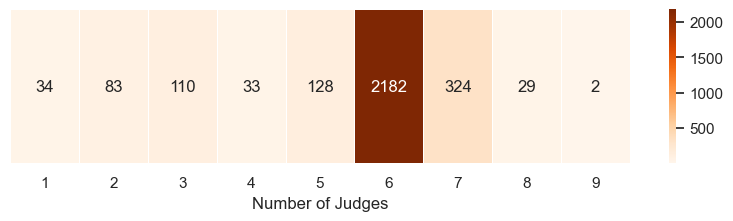

In [83]:
counts = (
    my_data_df.loc[my_data_df["judge_count"] <= 15, "judge_count"]
    .value_counts()
    .sort_index()
)

df.loc[rows, columns]
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))

sns.heatmap(
    counts.to_frame().T,
    cmap="Oranges",
    annot=True,
    fmt="d",
    cbar=True,
    linewidths=0.5
)

plt.xlabel("Number of Judges")
plt.yticks([])
plt.show()

some outliers with large values(>20) were observed indicating that there were decisions which required an extremely large number of judges. The heatmap shows that 6 judges are mentioned in most of the decisions.

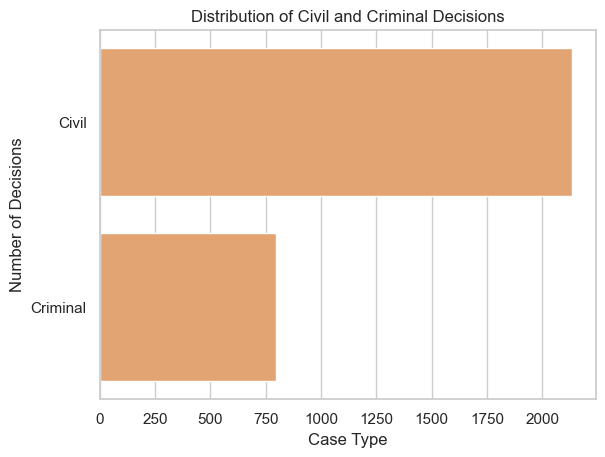

In [92]:
dept_type = my_data_df["dept"].str.contains("ΠΟΙΝΙΚΟ", case=False)

#replacing the booleans with string
case_type = dept_type.map({
    True: "Criminal",
    False: "Civil"
})

sns.countplot(
    y=case_type,
    color="#F4A261"
)

plt.xlabel("Case Type")
plt.ylabel("Number of Decisions")
plt.title("Distribution of Civil and Criminal Decisions")
plt.show()

THe number of cvil decisions is more than double the size of criminal decisions. This imbalance should be considered in future analyses. Results may be biased toward patterns found in civil decisions. Stratified sampling and class-specific evaluation metrics may therefore be necessary.